# Notebook 06

# Treinamento dos Modelos de Regressão

Após a implementação dos descritores AAC, AAL, CKSNAP e CKSAAGP, inicia-se a etapa de modelagem preditiva.

O objetivo deste notebook é avaliar a capacidade de diferentes algoritmos de Aprendizado de Máquina em predizer a energia de docking dos peptídeos da base SAGAPEP.

Para garantir uma comparação justa entre os métodos, todos os modelos serão treinados utilizando exatamente o mesmo protocolo experimental.

## Objetivos

Ao final deste notebook será possível:

- treinar diferentes modelos de regressão;

- utilizar validação cruzada 10-Fold;

- calcular métricas de desempenho;

- comparar os algoritmos;

- salvar todos os resultados para análise estatística posterior.

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

from sklearn.model_selection import KFold
from sklearn.model_selection import cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import make_scorer
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score
from sklearn.linear_model import BayesianRidge
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.neural_network import MLPRegressor

In [8]:
datasets = {

    "AAC":"../data/processed/aac_features.csv",
    "AAL":"../data/processed/aal_features.csv",
    "CKSNAP":"../data/processed/cksnap_features.csv",
    "CKSAAGP":"../data/processed/cksaagp_features.csv"
}

In [2]:
def load_dataset(path):
    df = pd.read_csv(path)
    X = df.drop(
        columns="best_docking_score"
    )
    y = df["best_docking_score"]
    return X,y

In [3]:
models = {
    "Bayesian Ridge":
        BayesianRidge(),
    "Random Forest":
        RandomForestRegressor(
            random_state=42
        ),
    "SVR":
        SVR(),
    "KNN":
        KNeighborsRegressor(),
    "MLP":
        MLPRegressor(
            random_state=42,
            max_iter=500
        )
}

In [4]:
def build_pipeline(model):
    if isinstance(
        model,
        RandomForestRegressor
    ):
        return Pipeline([
            ("model",model)
        ])
    return Pipeline([
        ("scaler",StandardScaler()),
        ("model",model)
    ])

## Estratégia experimental

Todos os modelos serão avaliados utilizando validação cruzada K-Fold com 10 partições, produzindo estimativas mais robustas e reduzindo a influência de uma única divisão entre treinamento e teste.

In [5]:
cv = KFold(
    n_splits=10,
    shuffle=True,
    random_state=42
)

In [6]:
scoring = {
    "RMSE":
        "neg_root_mean_squared_error",
    "MAE":
        "neg_mean_absolute_error",
    "MSE":
        "neg_mean_squared_error",
    "R2":
        "r2"
}

In [9]:
resultados = []

for nome_descritor,path in datasets.items():
    X,y = load_dataset(path)
    for nome_modelo,modelo in models.items():
        pipe = build_pipeline(modelo)
        scores = cross_validate(
            pipe,
            X,
            y,
            cv=cv,
            scoring=scoring,
            n_jobs=-1
        )

        resultados.append({
            "Descritor":
                nome_descritor,
            "Modelo":
                nome_modelo,
            "RMSE":
                -scores["test_RMSE"].mean(),
            "MAE":
                -scores["test_MAE"].mean(),
            "MSE":
                -scores["test_MSE"].mean(),
            "R2":
                scores["test_R2"].mean()
        })

In [10]:
resultados_df = pd.DataFrame(

    resultados

)

resultados_df

,Descritor,Modelo,RMSE,MAE,MSE,R2
0,AAC,Bayesian Ridge,15.290184,12.044500,238.380240,0.329847
1,AAC,Random Forest,13.986639,11.082725,199.096741,0.440377
2,AAC,SVR,17.969577,14.326082,326.618945,0.100273
3,AAC,KNN,17.172084,13.786135,296.611120,0.158558
4,AAC,MLP,43.282027,34.797557,1909.247664,-4.498858
5,AAL,Bayesian Ridge,17.412744,13.623219,314.355110,0.084735
6,AAL,Random Forest,16.184829,12.946412,265.092781,0.262813
7,AAL,SVR,19.002865,15.241445,365.269464,-0.005121
8,AAL,KNN,18.878433,15.441607,361.211360,-0.008085
9,AAL,MLP,69.711228,56.222279,4923.486905,-12.860704


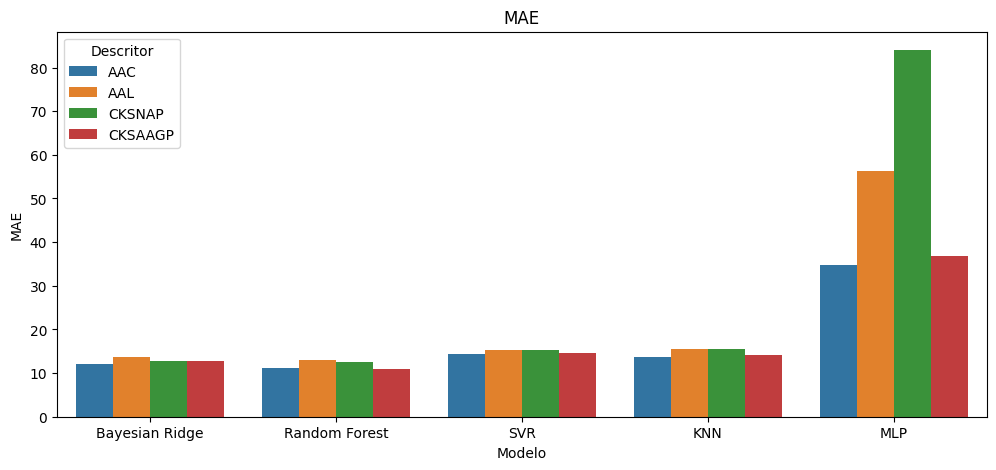

In [24]:
plt.figure(figsize=(12,5))
sns.barplot(
    data=resultados_df,
    x="Modelo",
    y="MAE",
    hue="Descritor"
)
plt.title(
    "MAE"
)
plt.show()

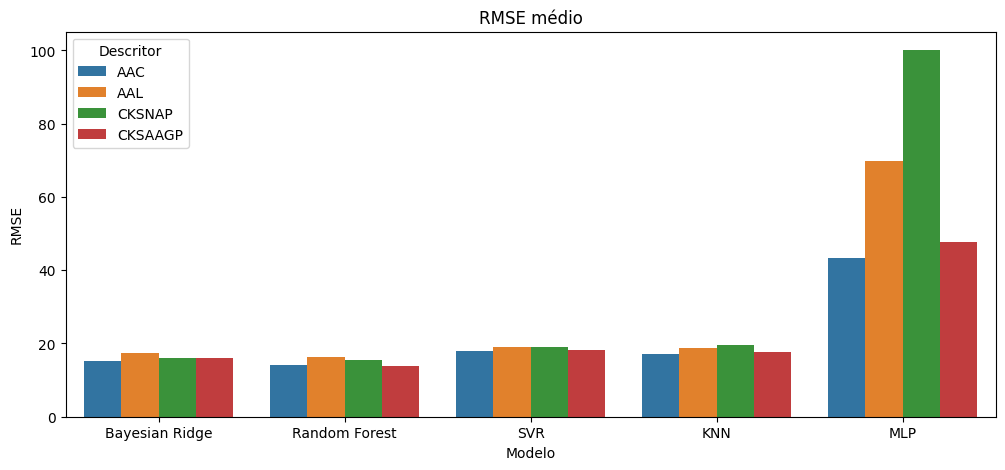

In [25]:
plt.figure(figsize=(12,5))
sns.barplot(
    data=resultados_df,
    x="Modelo",
    y="RMSE",
    hue="Descritor"
)
plt.title(
    "RMSE médio"
)
plt.show()

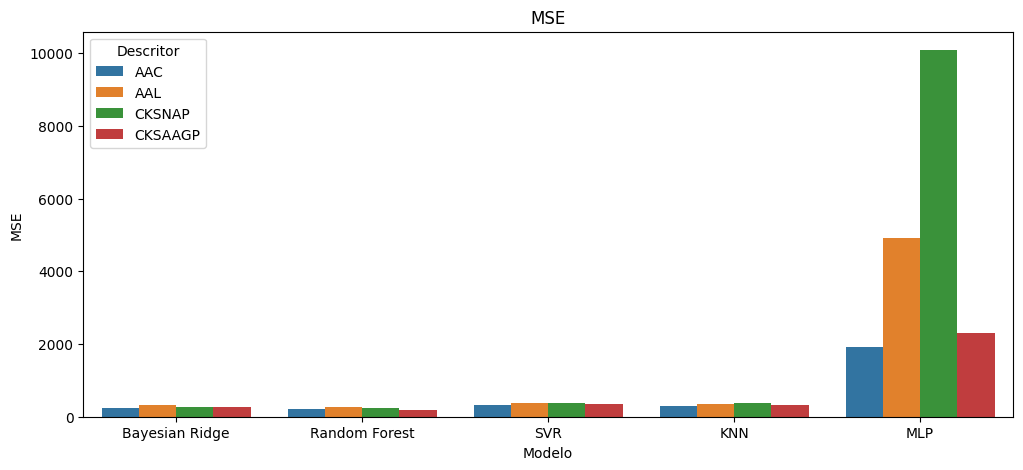

In [26]:
plt.figure(figsize=(12,5))
sns.barplot(
    data=resultados_df,
    x="Modelo",
    y="MSE",
    hue="Descritor"
)
plt.title(
    "MSE"
)
plt.show()

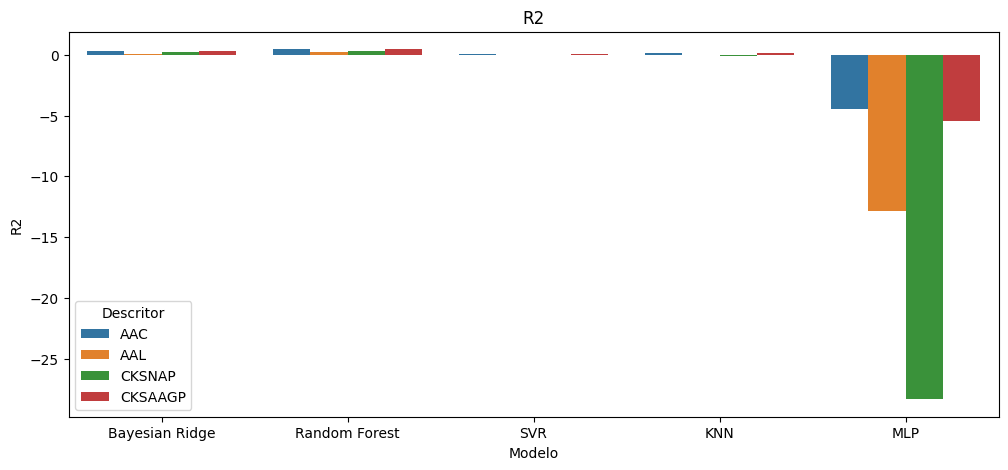

In [27]:
plt.figure(figsize=(12,5))
sns.barplot(
    data=resultados_df,
    x="Modelo",
    y="R2",
    hue="Descritor"
)
plt.title(
    "R2"
)
plt.show()

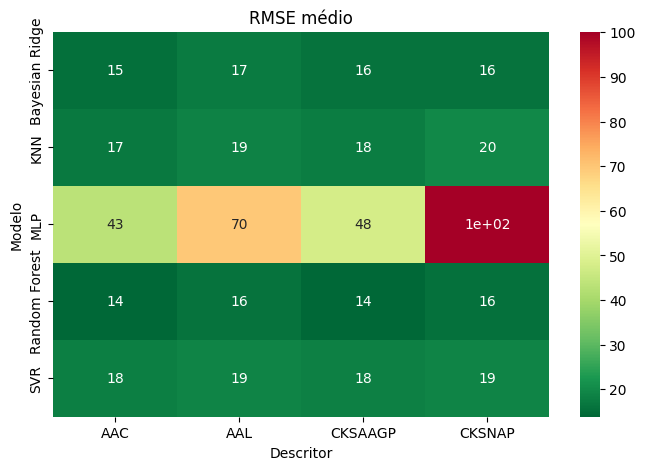

In [16]:
pivot = resultados_df.pivot(
    index="Modelo",
    columns="Descritor",
    values="RMSE"
)
plt.figure(figsize=(8,5))
sns.heatmap(
    pivot,
    annot=True,
    cmap="RdYlGn_r"
)

plt.title(
    "RMSE médio"
)
plt.show()

In [18]:
ranking = resultados_df.copy()

ranking["Rank RMSE"] = (
    ranking["RMSE"]
    .rank()
)

ranking["Rank MAE"] = (
    ranking["MAE"]
    .rank()
)

ranking["Rank R2"] = (
    ranking["R2"]
    .rank(
        ascending=False
    )
)

In [20]:
ranking["Rank Final"]=(
    ranking[
        [
            "Rank RMSE",
            "Rank MAE",
            "Rank R2"
        ]
    ]
    .mean(axis=1)
)

ranking.sort_values(
    "Rank Final"
)

,Descritor,Modelo,RMSE,MAE,MSE,R2,Rank RMSE,Rank MAE,Rank R2,Rank Final
16,CKSAAGP,Random Forest,13.852734,10.999410,195.081073,0.454635,1.0,1.0,1.0,1.000000
1,AAC,Random Forest,13.986639,11.082725,199.096741,0.440377,2.0,2.0,2.0,2.000000
0,AAC,Bayesian Ridge,15.290184,12.044500,238.380240,0.329847,3.0,3.0,3.0,3.000000
11,CKSNAP,Random Forest,15.622066,12.437582,246.774463,0.312352,4.0,4.0,4.0,4.000000
15,CKSAAGP,Bayesian Ridge,16.088278,12.764163,262.594072,0.268399,5.0,5.0,5.0,5.000000
10,CKSNAP,Bayesian Ridge,16.150574,12.785659,264.777103,0.258431,6.0,6.0,7.0,6.333333
6,AAL,Random Forest,16.184829,12.946412,265.092781,0.262813,7.0,7.0,6.0,6.666667
3,AAC,KNN,17.172084,13.786135,296.611120,0.158558,8.0,9.0,8.0,8.333333
5,AAL,Bayesian Ridge,17.412744,13.623219,314.355110,0.084735,9.0,8.0,11.0,9.333333
18,CKSAAGP,KNN,17.670834,14.167973,315.548910,0.117170,10.0,10.0,9.0,9.666667


In [23]:
resultados_df.to_csv(
    "../results/model_results.csv",
    index=False
)

ranking.to_csv(
    "../results/model_ranking.csv",
    index=False
)
print(
    "Resultados Salvos!"
)

Resultados Salvos!


## Conclusões

Neste notebook foram treinados cinco algoritmos clássicos de regressão utilizando os quatro descritores implementados ao longo deste trabalho.

Todos os modelos foram avaliados sob o mesmo protocolo experimental, empregando validação cruzada K-Fold com 10 partições e quatro métricas de desempenho (RMSE, MAE, MSE e \(R^2\)).

Os resultados obtidos constituem a base para a etapa seguinte, na qual será realizada uma comparação estatística entre os algoritmos e descritores por meio de testes de hipótese apropriados, permitindo identificar diferenças estatisticamente significativas entre as abordagens avaliadas.